<a href="https://colab.research.google.com/github/IgorVeret119/Deepfake_detective/blob/main/baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## `Загрузка данных (1 балл)`

In [1]:
!pip install yadisk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.7/140.7 kB 9.1 MB/s eta 0:00:00


In [2]:
TOKEN = "y0__wgBEOqqzbcEGIesRyC5wf_SGDDNzNLrB1UKpR0S6zv56ylh9XeIO-G_bAgG"

In [3]:
# ============================================
# БЛОК 2: Загрузка и РАСПАКОВКА АРХИВА
# ============================================

import yadisk
import zipfile
import io
import os
from tqdm import tqdm
import concurrent.futures
import requests

y = yadisk.YaDisk(token=TOKEN)

# Получаем ссылку на скачивание
print("Получение ссылки на скачивание...")
download_link = y.get_download_link("train_stage1_extracted_compressed.zip")
print(f"✅ Ссылка получена")

# Скачиваем архив на диск (НЕ В ПАМЯТЬ!)
print("Скачивание архива на диск...")
response = requests.get(download_link, stream=True)
total_size = int(response.headers.get('content-length', 0))

# Скачиваем в файл на диске
temp_zip = "temp_archive.zip"
with open(temp_zip, "wb") as f:
    with tqdm(total=total_size, unit='B', unit_scale=True, desc="Скачивание") as pbar:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
            pbar.update(len(chunk))

print(f"✅ Архив скачан на диск, размер: {os.path.getsize(temp_zip) / (1024**2):.2f} МБ")

# Распаковываем на диск (НЕ В ПАМЯТЬ!)
extract_dir = "extracted_files"
os.makedirs(extract_dir, exist_ok=True)

print("Распаковка на диск...")
with zipfile.ZipFile(temp_zip, 'r') as zip_ref:
    file_list = [f for f in zip_ref.infolist() if not f.is_dir()]
    print(f"Распаковка {len(file_list)} файлов...")

    for file_info in tqdm(file_list, desc="Распаковка"):
        zip_ref.extract(file_info, extract_dir)

print(f"✅ Распаковано {len(file_list)} файлов на диск")

# Удаляем временный архив
os.remove(temp_zip)
print("✅ Временный архив удален")

Получение ссылки на скачивание...
✅ Ссылка получена
Скачивание архива на диск...


Скачивание: 100%|██████████| 30.1G/30.1G [26:34<00:00, 18.9MB/s]


✅ Архив скачан на диск, размер: 28668.61 МБ
Распаковка на диск...
Распаковка 191499 файлов...


Распаковка: 100%|██████████| 191499/191499 [05:15<00:00, 607.47it/s]


✅ Распаковано 191499 файлов на диск
✅ Временный архив удален


In [4]:
import os

import numpy as np
import numpy.testing as npt
import pandas as pd
import torch
from torchvision.io import read_image
from torch.utils.data import Dataset, DataLoader
from torchvision.models import vgg13, VGG13_Weights
import torch
from sklearn.model_selection import train_test_split

from PIL import Image
from torchvision import transforms
import matplotlib_inline
import matplotlib.pyplot as plt

%matplotlib inline
matplotlib_inline.backend_inline.set_matplotlib_formats('pdf', 'svg')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
df = pd.read_csv('/content/extracted_files/stage1/train.csv')
data_list = list(zip( df['chng_img_path'], df['gt_path']))
train_list, test_list = train_test_split(data_list, test_size=0.2, random_state=42)

In [6]:
class TrainPhotosDataset(Dataset):
    def __init__(self, data_list, transforms=None):
        """
        Arguments
        ---------
        images_dir : str
            Path to directory with images

        target_dir : str
            Path to directory with masks.
            Each mask corresponds to one image.
            Corresponding mask and image have the same name, but different format.

        transforms : some collection
            Sequence of transformations for images and masks.

        """
        self.transforms=transforms
        self.data_list = data_list
    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        """
        Arguments
        ---------
        idx : int
            Index of image and mask

        Returns
        -------
        (image, mask)
        """
        to_tensor = transforms.ToTensor()


        image = to_tensor(Image.open(os.path.join('/content/extracted_files',self.data_list[idx][0])).convert('RGB'))
        mask = (to_tensor(Image.open(os.path.join('/content/extracted_files',self.data_list[idx][1])).convert('L')) > 0.5).float()
        image = transforms.Resize((224, 224))(image)
        mask = transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST)(mask)
        if self.transforms is not None:
          for transformer in self.transforms:
            image, mask = transformer(image,mask)
        return image,mask


#### `Просмотр данных`

## `Модуль аугментации (2 балла)`

In [7]:
class RandomHorizontal(object):
  def __init__(self,p):
    self.p=p
  def __call__(self,x,mask=None):
    if torch.rand(1).item() < self.p:
      return (torch.flip(x, dims=[-1]), None if mask is None else torch.flip(mask,dims=[-1]))
    return (x,mask)
  def __repr__(self):
    return f"Horizontal(p={self.p})"
class RandomCrop(object):
    def __init__(self, p, size=None, random_size=(0,1,0,1)):
        self.p = p
        self.size = size
        self.random_size=random_size
    def __call__(self, x, mask=None):
        if torch.rand(1).item() < self.p:
            if self.size is not None:
                x_coord,y_coord,weight,height=self.size
            else:
                h, w = x.shape[-2], x.shape[-1]
                a,b,c,d=self.random_size
                weight=torch.randint(int(c*w),int(d*w),(1,))
                height=torch.randint(int(a*h),int(b*h),(1,))
                x_coord=torch.randint(0,w-weight,(1,))
                y_coord=torch.randint(0,h-height,(1,))
            new_mask=torch.zeros(x.shape)
            new_mask[...,y_coord:y_coord+height,x_coord:x_coord+weight]=1
            new_mask_for_mask=torch.zeros(mask.shape)
            new_mask_for_mask[...,max(0,y_coord-height//10):min(mask.shape[-2],y_coord+height+height//10),
                              max(0,x_coord-weight//10):min(mask.shape[-1],x_coord+weight+weight//10)]=1
            #return (x*new_mask,mask)
            return (x*new_mask,None if mask is None else mask*new_mask_for_mask)
        return (x,mask)
        F.interpolate(x_batch, size=target_size, mode='bilinear', align_corners=False)
class RandomBright(object):
  def __init__(self,p,value=None,mean=0,std=0.1):
    self.p=p
    self.value=value
    self.std=std
    self.mean=mean
  def __call__(self,x,mask=None):
    if torch.rand(1).item() < self.p:
      if self.value is not None:
        x=x+self.value
      else:
        x=x+(torch.randn((1,))*self.std+self.mean)*x.mean()
    return (x,mask)
class RandomBackground(object):
    def __init__(self, p, images_list, masks_list):
        self.p = p
        self.images_list = images_list
        self.masks_list = masks_list

    def __call__(self, x, mask):
        if torch.rand(1).item() < self.p:
            n = torch.randint(0, len(self.images_list), (1,)).item()
            image = self.images_list[n]
            bg_mask = self.masks_list[n]
            x_new = x.clone()
            anti_mask = (mask == 0).bool().squeeze(0)
            for c in range(3):
              x_new[c, anti_mask] = image[c, anti_mask].float()
            bg_mask_norm = bg_mask.float()
            combined_mask = torch.max(mask.float(), bg_mask_norm)

            return (x_new, combined_mask)
        return (x, mask)

In [8]:
train_dataset = TrainPhotosDataset(
    data_list=train_list,
    transforms=[RandomHorizontal(0.25),RandomCrop(0.25),RandomBright(0.25)]
)

test_dataset = TrainPhotosDataset(
    data_list=test_list
)

Функция для отображения изображения:

In [9]:
def show_idx_image(dataset, idx):
    image, mask = dataset[idx]

    image = image.permute(1, 2, 0).numpy()
    image = (image * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
    image = np.clip(image, 0, 1)

    mask = mask.squeeze(0).numpy()

    fig, axes = plt.subplots(1, 2, figsize=(6, 4))

    axes[0].imshow(image)
    axes[1].imshow(mask)

    axes[0].set_axis_off()
    axes[1].set_axis_off()

    fig.tight_layout()
    plt.show()

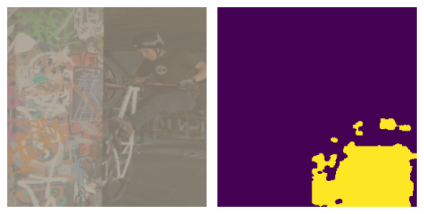

In [10]:
test_dataset_1 = TrainPhotosDataset(
    data_list=train_list,
    transforms=[RandomHorizontal(1)]
)
show_idx_image(test_dataset_1,0)

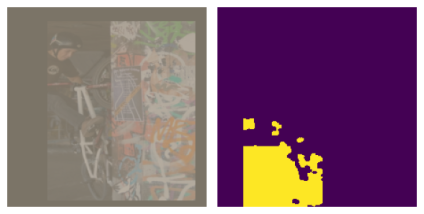

In [11]:
test_dataset_1 = TrainPhotosDataset(
    data_list=train_list,
    transforms=[RandomCrop(1)]
)
show_idx_image(test_dataset_1,0)

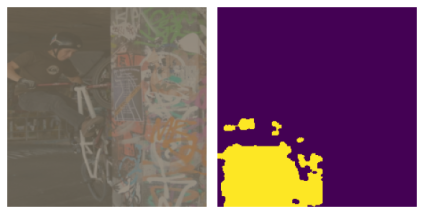

In [12]:
test_dataset_1 = TrainPhotosDataset(
    data_list=train_list,
    transforms=[RandomBright(1,-0.5)]
)
show_idx_image(test_dataset_1,0)

## `Загрузчики`

In [13]:
test_data_loader = DataLoader(test_dataset, batch_size=8, num_workers=3)
train_data_loader = DataLoader(train_dataset, batch_size=8, num_workers=3, shuffle=True)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 3 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## `DiceLoss (1 балл)`

In [14]:
class DiceLoss(torch.nn.Module):
    def __init__(self, eps=1e-7, reduction=None, with_logits=True):
        """
        Arguments
        ---------
        eps : float
            eps in denominator
        reduction : Optional[str] (None, 'mean' or 'sum')
            specifies the reduction to apply to the output:

            None: no reduction will be applied
            'mean': the sum of the output will be divided by the number of elements in the batch
            'sum':  the output will be summed.
        with_logits : bool
            If True, use additional sigmoid for inputs
        """
        super().__init__()
        self.eps = eps
        self.reduction = reduction
        self.with_logits = with_logits

    def forward(self, logits, true_labels):
        """
        Arguments
        ---------
        logits: torch.Tensor
            Unnormalized probability of true class. Shape: [B, ...]
        true_labels: torch.Tensor
            Mask of correct predictions. Shape: [B, ...]
        Returns
        -------
        torch.Tensor
            If reduction is 'mean' or 'sum' returns a tensor with a single element
            Otherwise, returns a tensor of shape [B]
        """
        true_labels = true_labels.to(torch.long)

        if self.with_logits:
            logits=torch.sigmoid(logits)
        axis=(tuple(range(1, logits.ndim)))
        a=(2*logits*true_labels).sum(dim=axis)
        b=logits.sum(dim=axis)+self.eps
        c=true_labels.sum(dim=axis)
        res=torch.ones((logits.shape[0],)).to(device)-a/(b+c)

        if self.reduction == 'sum':
            # your code here
            loss_value = res.sum()
        elif self.reduction == 'mean':
            # your code here
            loss_value = res.mean()
        elif self.reduction is None:
            # your code here
            loss_value = res

        return loss_value

Проверка реализации:

In [15]:
logits = torch.tensor([
    [[0, 0.5], [0.5, 1]],
    [[0.1, 0.1], [0, 0]],
]).to(device)

target = torch.tensor([
    [[0, 1], [1, 1]],
    [[1, 0], [0, 1]],
]).to(device)

losses = DiceLoss(with_logits=False, reduction=None, eps=1e-7)(logits, target)
npt.assert_almost_equal(losses.cpu().numpy(), np.array([0.2, 0.90909]), decimal=4)

loss = DiceLoss(with_logits=False, reduction='mean', eps=1e-7)(logits, target)
npt.assert_almost_equal(float(loss.cpu().numpy()), 0.554545, decimal=4)

loss = DiceLoss(with_logits=False, reduction='sum', eps=1e-7)(logits, target)
npt.assert_almost_equal(float(loss.cpu().numpy()), 1.10909, decimal=4)

## `U-Net (3 балла)`

#### `Encoder`

In [16]:
from torch import nn
from copy import deepcopy
class VGG13Encoder(torch.nn.Module):
    def __init__(self, num_blocks, weights=VGG13_Weights.DEFAULT):
        super().__init__()
        self.num_blocks = num_blocks

        # Будем использовать предобученную VGG13 в качестве backbone
        feature_extractor = vgg13(weights=weights).features

        # Каждый блок энкодера U-Net — это блок VGG13 без MaxPool2d
        self.blocks = torch.nn.ModuleList()
        tmp=[]
        cur=0
        for idx in range(self.num_blocks):
            # Возьмите нужные слои из `feature_extractor` для очередного U-Net блока
            # Объедините их с помощью `torch.nn.Sequential`
            tmp=[]
            while(not isinstance(feature_extractor[cur],nn.MaxPool2d)):
              tmp.append(deepcopy(feature_extractor[cur]))
              cur+=1
            self.blocks.append(
                  nn.Sequential(*tmp)
            )
            cur+=1
        self.MP=nn.MaxPool2d(kernel_size=2, stride=2, padding=0)


    def forward(self, x):
        activations = []
        for idx, block in enumerate(self.blocks):
            # Примените очередной блок U-Net
            # your code here
            x=block(x)

            # Сохраните активации для передачи их в декодер
            # your code here
            activations.append(x)

            # При необходимости примените max-pool
            # Можно использовать `torch.functional.F.max_pool2d`
            # your code here
            x=self.MP(x) if idx!=len(self.blocks)-1 else x

        return activations

In [17]:
assert sum((param.numel() for param in VGG13Encoder(num_blocks=1).parameters())) == 38720
assert sum((param.numel() for param in VGG13Encoder(num_blocks=2).parameters())) == 260160
assert sum((param.numel() for param in VGG13Encoder(num_blocks=3).parameters())) == 1145408

x = torch.arange(1 * 3 * 320 * 240).reshape(1, 3, 320, 240) / (1 * 3 * 320 * 240)
out = VGG13Encoder(num_blocks=3)(x)

assert len(out) == 3
npt.assert_almost_equal(torch.linalg.norm(out[0]).item(), 902.218, decimal=3)
npt.assert_almost_equal(torch.linalg.norm(out[1]).item(), 571.030, decimal=3)
npt.assert_almost_equal(torch.linalg.norm(out[2]).item(), 648.068, decimal=3)

Downloading: "https://download.pytorch.org/models/vgg13-19584684.pth" to /root/.cache/torch/hub/checkpoints/vgg13-19584684.pth


100%|██████████| 508M/508M [00:06<00:00, 84.3MB/s]


#### `Decoder`

In [18]:
import torch.nn.functional as F
class DecoderBlock(torch.nn.Module):
    def __init__(self, out_channels):
        super().__init__()

        self.upconv = torch.nn.Conv2d(
            in_channels=out_channels * 2, out_channels=out_channels,
            kernel_size=3, padding=1, dilation=1
        )
        self.conv1 = torch.nn.Conv2d(
            in_channels=out_channels * 2, out_channels=out_channels,
            kernel_size=3, padding=1, dilation=1
        )
        self.conv2 = torch.nn.Conv2d(
            in_channels=out_channels, out_channels=out_channels,
            kernel_size=3, padding=1, dilation=1
        )
        self.relu = torch.nn.ReLU()

    def forward(self, down, left):
        # Upsample x2 и свёртка
        # your code here
        x = F.interpolate(down, scale_factor=2, mode='nearest')
        x=self.upconv(x)

        # Конкатенация выхода энкодера и предыдущего блока декодера
        # your code here
        x = torch.cat([x,left],dim=1)

        # Две свёртки с ReLu
        # your code here
        x = self.conv1(x)
        x=self.relu(x)
        x = self.conv2(x)
        x=self.relu(x)

        return x

In [19]:
class Decoder(torch.nn.Module):
    def __init__(self, num_filters, num_blocks):
        super().__init__()

        self.blocks = torch.nn.ModuleList()
        for idx in range(num_blocks):
            self.blocks.insert(0, DecoderBlock(num_filters * 2 ** idx))

    def forward(self, acts):
        up = acts[-1]
        for block, left in zip(self.blocks, acts[-2::-1]):
            up = block(up, left)
        return up

#### `U-Net`

In [20]:
class UNet(torch.nn.Module):
    def __init__(self, num_classes=1, num_blocks=4):
        super().__init__()
        # your code here
        self.encoder = VGG13Encoder(num_blocks)

        # your code here
        self.decoder = Decoder(64,num_blocks-1)

        # Свёртка 1x1 для попиксельной агрегации каналов
        # your code here
        self.final = torch.nn.Conv2d(
            in_channels=64, out_channels=num_classes,
            kernel_size=1,
        )

    def forward(self, x):
        x=self.encoder(x)
        x=self.decoder(x)
        x=self.final(x)

        return x

In [21]:
model = UNet(num_classes=1, num_blocks=3)
x = torch.arange(1 * 3 * 320 * 240).reshape(1, 3, 320, 240) / (1 * 3 * 320 * 240)
assert sum((param.numel() for param in model.parameters())) == 2067649
assert list(model(x).shape) == [1, 1, 320, 240]
model

UNet(
  (encoder): VGG13Encoder(
    (blocks): ModuleList(
      (0): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU(inplace=True)
      )
      (1): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU(inplace=True)
      )
      (2): Sequential(
        (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU(inplace=True)
      )
    )
    (MP): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Decoder(
    (blocks): ModuleList(
      (0): DecoderBlock(
        

### `Оценивание качества сети`


Обычно, оптимизируемый функционал сложно интерпретировать, а так же в разных экспериментах могут использоваться разные функции потерь. Поэтому необходимо замерять и отслеживать независимую метрику качества. Предлагается использовать **IoU (Intersection over Union)** — один из стандартных вариантов для задачи сегментации:
$$
\text{IoU} = \frac{|A \cap B|}{|A \cup B|} = \frac{\sum\limits_{ij}a_{ij}b_{ij}}{\sum\limits_{ij}a_{ij} + b_{ij} - a_{ij}b_{ij}}
$$

Учтите, что знаменатель может быть равен нулю, например, если маска нулевая. Такие объекты можно не учитывать при агрегации и пропускать, так как в ином случае подсчет метрики на всем батче будет NaN. В pytorch есть встроенные для этого функции с префиксом nan.


In [22]:
class IoUScore(torch.nn.Module):
    def __init__(self, threshold, reduction=None,with_logits=True):
        """
        Arguments
        ---------
        threshold : float
            threshold for logits binarization
        reduction : Optional[str] (None, 'mean' or 'sum')
            specifies the reduction to apply to the output:

            None: no reduction will be applied
            'mean': the sum of the output will be divided by the number of elements in the batch
            'sum':  the output will be summed.
        with_logits : bool
            If True, use additional sigmoid for inputs
        """
        super().__init__()

        self.threshold = threshold
        self.reduction = reduction
        self.with_logits=with_logits
    @torch.no_grad()
    def forward(self, logits, true_labels):
        """
        Arguments
        ---------
        logits: torch.Tensor
            Unnormalized probability of true class. Shape: [B, ...]
        true_labels: torch.Tensor
            Mask of correct predictions. Shape: [B, ...]
        Returns
        -------
        torch.Tensor
            If reduction is 'mean' or 'sum' returns a tensor with a single element
            Otherwise, returns a tensor of shape [B]
        """
        if(self.with_logits):
          logits=torch.sigmoid(logits)
        logits=(logits>self.threshold).float()
        axis=[i for i in range(1,logits.ndim)]
        a=(logits*true_labels).sum(dim=axis)
        b=logits.sum(dim=axis)
        c=true_labels.sum(dim=axis)
        score=a/(b+c-a)

        if self.reduction == 'sum':
            # your code here
            score = torch.nansum(score)
        elif self.reduction == 'mean':
            # your code here
            score = torch.nanmean(score)

        return score

In [23]:
logits = torch.tensor([
    [
        [0.3089,  0.4311, -0.9711],
        [0.9030,  1.0325, -0.7607],
        [0.9648, -0.5528, -1.1010]
    ], [
        [0.8906,  0.8099,  0.4458],
        [2.6215, -1.3198,  0.3142],
        [0.2262, -0.9175, -0.0174]
    ], [
        [0.8906,  0.8099,  0.4458],
        [2.6215, -1.3198,  0.3142],
        [0.2262, -0.9175, -0.0174]
    ]
])
true_labels = torch.tensor([
    [
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 0., 1.]
    ], [
        [1., 1., 1.],
        [1., 0., 1.],
        [1., 0., 0.]
    ], [
        [1., 1., 1.],
        [0., 1., 1.],
        [1., 1., 1.]
    ]
])

scores = IoUScore(0.0,with_logits=False)(logits, true_labels)
npt.assert_almost_equal(scores.numpy(), np.array([0.3333, 1.0000, 0.5556]), decimal=4)

score = IoUScore(0.0, reduction='sum',with_logits=False)(logits, true_labels)
npt.assert_almost_equal(score.item(), 1.8889, decimal=4)

score = IoUScore(0.0, reduction='mean',with_logits=False)(logits, true_labels)
npt.assert_almost_equal(score.item(), 0.6296, decimal=4)

### `Логирование`

При реализации цикла обучения необходимо сохранять метрики $1\text{-}9$ с использованием модуля [torch.utils.tensorboard](https://pytorch.org/docs/stable/tensorboard.html) или с помощью модуля [wandb](https://docs.wandb.ai/tutorials/) вам предлагается самим выбрать более удобный для вас модуль.

Для отслеживания процесса обучения обычно требуется сохранять информацию разных его аспектах.

Для полного контроля над процессом обучения обычно требуется сохранять информацию о разных статистиках. Самыми очевидными являются:
1. Значение функции потерь (лосса) на обучающей и тестовой выборках
2. Метики качества, например, **Dice Coefficient** и **IoU (Intersection over Union)** на обучающей и тестовой выборках

Однако, суррогатные метрики могут не отражать реального качества. Поэтому для моделей, которые выдают визуализируемый результат, обычно логируют предсказания для некоторых объектов выборки. В задаче сегментации естественным вариантом является логирование четвёрки: исходное изображение, истинная маска, маска вероятностей истинного класса, бинаризованная маска.

*Замечание:* лосс и качество на обучающей выборке обычно логируют не только в конце каждой эпохи, но и по отдельным батчам на каждой итерации.

3. Чтобы отслеживать динамику обучения необходимо зафиксировать небольшой набор объектов обучающей и тестовой выборок и после каждой эпохи обучения логировать указанные четыре картинки для каждого объекта.

*Замечание:* можно логировать четвёрки изображений независимо, однако, удобнее объединить их на одной фигуре [реализация через Tensorboard](https://pytorch.org/docs/stable/tensorboard.html#torch.utils.tensorboard.writer.SummaryWriter.add_figure), [реализация через Wandb](https://docs.wandb.ai/guides/track/log/plots/#matplotlib-and-plotly-plots) (лучше делать через fig и Image). Дополнительный плюс — возможность подписать значения метрик для этого объекта в заголовке изображения или добавить colorbar для более простой интерпретации предсказанной маски.

Для удобной категоризации экспериментов обычно в начале обучения сохраняют:

4. Гиперпараметры модели [реализация через Tensorboard](https://pytorch.org/docs/stable/tensorboard.html#torch.utils.tensorboard.writer.SummaryWriter.add_hparams), [реализация через Wandb](https://docs.wandb.ai/guides/track/config/)
5. Структуру модели [реализация через Tensorboard](https://pytorch.org/docs/stable/tensorboard.html#torch.utils.tensorboard.writer.SummaryWriter.add_graph), **про реализацию wandb ниже**

Для исследования технических особенностей обучения полезно логировать следующие статистики:

6. Распределение весов, активаций, градиентов [реализация через Tensorboard](https://pytorch.org/docs/stable/tensorboard.html#torch.utils.tensorboard.writer.SummaryWriter.add_histogram), [реализация через Wandb](https://docs.wandb.ai/ref/python/data-types/histogram/). Сохранять гистограммы каждого параметра после каждой итерации может быть вычислительно неэффективно, поэтому обычно сохраняют распределения весов для каждого отдельного слоя нейронной сети после каждой эпохи.
7. Норма весов и норма градиента на каждой итерации

Наконец, после каждой эпохи можно визуализировать промежуточные представления входных данных:

8. Активации после каждого слоя/блока, как изображения
9. Градиенты функции потерь по активациям для некоторых объектов обучающей выборки, как изображения

*Замечание:* для реализации пунктов 8, 9 менять код модели не требуется. Используйте хуки: [register_full_backward_hook](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook) (данный хук не работает с inplace операциями, например, с `torch.nn.ReLU(inplace=True)`. Или не используйте inplace операции, или используйте [`Tensor.register_hook`](https://github.com/pytorch/pytorch/issues/61519)), [register_forward_hook](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_forward_hook).

Файлы с логами, а также чекпоинты весов модели после итерации с наилучшим валидационным качеством (смотрите [torch.save](https://pytorch.org/docs/stable/generated/torch.save.html) и [torch.nn.Module.state_dict](https://pytorch.org/tutorials/recipes/recipes/what_is_state_dict.html)) для **ВСЕХ** проведённых экспериментов (за исключением упавших, недосчитанных и так далее) необходимо сдать в anytask.

#### `Некоторые советы по wandb`

- При логировании всегда указывайте параметр step, который должен не уменьшаться.

- При логировании изображений лучше их нормировать в диапазон [0, 1] как в функции `show_idx_image` выше. Для логирования предсказаний маски, лучше использовать вероятности. При неправильном диапозоне изображения могут отображаться неверно!

- Вместо логирования изображений, лучше логировать `matplotlib` графики и соответсвующие им `figure`. Кроме того, лучше закрывать все открытые графики, чтобы не перегружать ноутбук. Пример кода:


```python
fig, ax = plt.subplots(...)
...
wandb.log({key: wandb.Image(fig)}, step=global_step)
plt.close('all')
```

- Функционал построение bins в `wandb.Histogram` ограничен, можете посмотреть в сторону аргумента `np_histogram`.

- Wandb не имеет широкого функционала для логирования структуры модели. Есть способ через wandb.watch(net, log_graph=True), но получаемый результаты сильно отличаются от возможностей `tensorboard`. К счастью, `wandb` умеет синхронизировать логи с `Tensorboard` поэтому можно использовать следующую логику:


```python
wandb.init(
    project=project_name,
    name=run_name,
    config=config,
    sync_tensorboard=True        # Синхронизация с tensorboard
)

writer = SummaryWriter(run_name) # Создание логера tensorboard

# Логирование графа модели
writer.add_graph(net, input_x)
writer.close()

train_loop(...)
wandb.finish()
```

- `wandb` по умолчанию сохраняет все логи локально и на сайте в вашем личном хранилище. В случае перезагрузки `Google Colab` локальные файлы не сохраняются! Кроме того, скачивание файлов не через GoogleDisk достаточно продолжительное (в районе 20-30 минут).

- В `wandb` можно легко сохранять код и указать директорию, так вы никогда не забудете какой именно код получает результаты логов.

```python
wandb.init(..., settings=wandb.Settings(code_dir="."))
```

Кроме того, можно сохранить отдельные файлы:

```python
wandb.init(..., save_code=True)
wandb.run.log_code(
    "./",
    include_fn=lambda path: condition(path)
)
```

- В `wandb` есть функция для автоматического логирования весов и градиентов модели `wandb.watch()`, но функционал слишком ограничен и накладывает слишком много накладных расходов. **Лучше писать руками!**

#### `Некоторые советы по tensorboard`

- Функционал и возможности `tensorboard` шире (работа с 3D, продвинутые визуализации).

- `tensorboard` сохраняет логи только локально, то есть после закрытия `Google Colab` ничего не сохранится. В реальных проектах это является сильной стороной, так как гарантирует безопасность и конфиденциальность.

- Для визуализации логов достаточно запустить в ноутбуке или в терминале соответсвующее расширение, однако в случае `Google Colab` для этого приходится прокидывать порты, [подробнее тут](https://stackoverflow.com/questions/47818822/can-i-use-tensorboard-with-google-colab).

- `tensorboard` меньше лагает и более легковесный.


### `Некоторые советы по логированию`

- Вы можете выбрать либо `wandb`, либо `tensorboard`.

- В реальных проектах лучше добавить логирование кода с целью сохранения и воспроизводимости результатов.

- Называйте запуски осмысленно, чтобы по названию можно было понять смысл запуска и варьеруемые параметры.


### `Эксперименты`

In [28]:
from tqdm.notebook import tqdm
from torch.utils.tensorboard import SummaryWriter
import yadisk
import os
import torch
import shutil

def train_model(train_loader,test_loader,loss_func=DiceLoss(reduction='mean'),
                lr=0.01,optim=torch.optim.Adam,
                eval_func=IoUScore(0.8,reduction='mean'),epochs=4,num_blocks=4,
                dir_to_log=None, yandex_token=None, yandex_path=None,
                load_checkpoint=False):

    model = UNet(num_classes=1, num_blocks=num_blocks).to(device)
    optimizer = optim(model.parameters(), lr=lr)

    start_epoch = 0

    # Инициализация Яндекс Диска
    yandex_client = None
    if yandex_token is not None:
        yandex_client = yadisk.YaDisk(token=yandex_token)

    # Загрузка чекпоинта с Яндекс Диска
    if load_checkpoint and yandex_client is not None and yandex_path is not None:
        remote_checkpoint = f"{yandex_path}/checkpoint_latest.pth"
        local_checkpoint = "/tmp/checkpoint_latest.pth"

        if yandex_client.exists(remote_checkpoint):
            print(f"📥 Загрузка чекпоинта с Яндекс Диска: {remote_checkpoint}")
            yandex_client.download(remote_checkpoint, local_checkpoint)

            checkpoint = torch.load(local_checkpoint, map_location=device)

            # Проверяем структуру чекпоинта
            if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
                # Если есть model_state_dict - загружаем из него
                model.load_state_dict(checkpoint['model_state_dict'])

                optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
                start_epoch = checkpoint['epoch'] + 1
                print(f"✅ Чекпоинт загружен. Продолжаем с эпохи {start_epoch}")
                print(f"   Потеря на валидации: {checkpoint.get('loss', 'N/A')}")
                print(f"   IoU на валидации: {checkpoint.get('iou', 'N/A')}")
            elif isinstance(checkpoint, dict) and all(isinstance(v, torch.Tensor) for v in checkpoint.values()):
                # Если это просто model.state_dict() (OrderedDict)
                model.load_state_dict(checkpoint)
                print("✅ Чекпоинт загружен (model.state_dict()). Начинаем с эпохи 0")
            else:
                print("❌ Неизвестная структура чекпоинта")

            os.remove(local_checkpoint)
        else:
            print("ℹ️ Чекпоинт на Яндекс Диске не найден. Начинаем с нуля.")

        # Загрузка логов с Яндекс Диска
        remote_logs = f"{yandex_path}/logs"
        local_logs = dir_to_log

        if yandex_client.exists(remote_logs) and local_logs is not None:
            print(f"📥 Загрузка логов с Яндекс Диска: {remote_logs}")

            os.makedirs(local_logs, exist_ok=True)

            for item in yandex_client.listdir(remote_logs):
                if item.type == "file":
                    remote_file = f"{remote_logs}/{item.name}"
                    local_file = os.path.join(local_logs, item.name)
                    yandex_client.download(remote_file, local_file)
                    print(f"   Загружен: {item.name}")

            print("✅ Логи загружены с Яндекс Диска")
        else:
            print("ℹ️ Логи на Яндекс Диске не найдены. Создаём новые.")

    if not(dir_to_log is None):
        writer = SummaryWriter(dir_to_log)
        writer.global_step = start_epoch * len(train_loader)
        etalone = [test_loader.dataset[i] for i in [0,5,7,9]]
        n=0
        for X,y in etalone:
            n+=1
            pred=model(X.unsqueeze(0).to(device))
            pred=(torch.sigmoid(pred)>0.8).float()
            writer.add_image(f'Images/example_{n}/Image', X.squeeze(0), writer.global_step, dataformats='CHW')
            writer.add_image(f'Images/example_{n}/Mask', y, writer.global_step, dataformats='CHW')
            writer.add_image(f'Images/example_{n}/Result', pred.cpu().squeeze(0), writer.global_step, dataformats='CHW')

    last_val_loss = None
    last_val_iou = None

    for epoch in tqdm(range(start_epoch, epochs), position=0, leave=True):
        model.train()
        for X,y in tqdm(train_loader, position=1, leave=False):
            X = X.to(device)
            y = y.to(device)
            pred = model(X)
            loss = loss_func(pred, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if not(dir_to_log is None):
                with torch.no_grad():
                    writer.add_scalar('Loss/train_step', loss.item(), writer.global_step)
                    writer.add_scalar('Eval/train_step', eval_func(pred, y).item(), writer.global_step)
                    total_weight_norm = sum(p.norm().item() ** 2 for name, p in model.named_parameters() if 'weight' in name) ** 0.5
                    total_grad_norm = sum(p.grad.norm().item() ** 2 for name, p in model.named_parameters() if p.grad is not None and 'weight' in name) ** 0.5
                    writer.add_scalar('Norm/weights', total_weight_norm, writer.global_step)
                    writer.add_scalar('Norm/grad', total_grad_norm, writer.global_step)
                    writer.global_step += 1

        if not(dir_to_log is None):
            for name, param in model.named_parameters():
                if 'weight' in name:
                    writer.add_histogram(f'weights/{name}', param, epoch)
            for name, param in model.named_parameters():
                if param.grad is not None and 'weight' in name:
                    writer.add_histogram(f'gradients/{name}', param.grad, epoch)

            with torch.no_grad():
                model.eval()
                numb = 0
                loss = 0
                eval = 0
                for X, y in test_loader:
                    X = X.to(device)
                    y = y.to(device)
                    numb += 1
                    pred = model(X)
                    loss += loss_func(pred, y).item()
                    eval += eval_func(pred, y).item()

                last_val_loss = loss / numb
                last_val_iou = eval / numb
                writer.add_scalar('Loss/test_step', last_val_loss, writer.global_step)
                writer.add_scalar('Eval/test_step', last_val_iou, writer.global_step)

                n = 0
                for X, y in etalone:
                    n += 1
                    pred = model(X.unsqueeze(0).to(device))
                    pred = (torch.sigmoid(pred) > 0.8).float()
                    writer.add_image(f'Images/example_{n}/Image', X.squeeze(0), writer.global_step, dataformats='CHW')
                    writer.add_image(f'Images/example_{n}/Mask', y, writer.global_step, dataformats='CHW')
                    writer.add_image(f'Images/example_{n}/Result', pred.cpu().squeeze(0), writer.global_step, dataformats='CHW')

        # Сохранение чекпоинта на Яндекс Диск
        if yandex_client is not None and yandex_path is not None:
            local_checkpoint = f"/tmp/checkpoint_epoch_{epoch}.pth"
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': last_val_loss,
                'iou': last_val_iou,
            }, local_checkpoint)

            remote_path = f"{yandex_path}/checkpoint_epoch_{epoch}.pth"
            remote_latest = f"{yandex_path}/checkpoint_latest.pth"

            remote_dir = os.path.dirname(remote_path)
            if not yandex_client.exists(remote_dir):
                yandex_client.mkdir(remote_dir, recursive=True)

            yandex_client.upload(local_checkpoint, remote_path, overwrite=True)
            yandex_client.upload(local_checkpoint, remote_latest, overwrite=True)
            print(f"✅ Чекпоинт сохранён на Яндекс Диск: {remote_path}")

            os.remove(local_checkpoint)

        # Сохранение логов на Яндекс Диск ПОСЛЕ КАЖДОЙ ЭПОХИ
        if yandex_client is not None and yandex_path is not None and dir_to_log is not None:
            remote_logs = f"{yandex_path}/logs"
            if not yandex_client.exists(remote_logs):
                yandex_client.mkdir(remote_logs, recursive=True)

            print("📤 Загрузка логов на Яндекс Диск (после эпохи {})...".format(epoch))
            for root, dirs, files in os.walk(dir_to_log):
                for file in files:
                    local_path = os.path.join(root, file)
                    rel_path = os.path.relpath(local_path, dir_to_log)
                    remote_path = f"{remote_logs}/{rel_path}"

                    remote_dir = os.path.dirname(remote_path)
                    if not yandex_client.exists(remote_dir):
                        yandex_client.mkdir(remote_dir, recursive=True)

                    yandex_client.upload(local_path, remote_path, overwrite=True)

            print(f"✅ Логи сохранены на Яндекс Диск: {remote_logs}")

    if dir_to_log is not None:
        writer.add_hparams(
            {'lr': lr, 'loss_func': type(loss_func).__name__, 'eval_func': type(eval_func).__name__,
             'threshold': 0.8, 'n_epochs': epochs, 'optimizer': optim.__name__, 'num_blocks': num_blocks},
            {'final_loss': last_val_loss, 'final_quality': last_val_iou}
        )
        writer.close()

    # Сохранение финальной модели
    if yandex_client is not None and yandex_path is not None:
        local_final = "/tmp/final_model.pth"
        torch.save(model.state_dict(), local_final)
        remote_final = f"{yandex_path}/final_model.pth"
        yandex_client.upload(local_final, remote_final, overwrite=True)
        print(f"✅ Финальная модель сохранена на Яндекс Диск: {remote_final}")
        os.remove(local_final)

    return model

In [ ]:
import warnings
import time
warnings.filterwarnings("ignore", category=UserWarning)
t_start=time.time()
if not y.exists('/IoU'):
    y.mkdir('/IoU', recursive=True)
model=train_model(train_data_loader,test_data_loader,epochs=30,lr=0.0001,dir_to_log='/content/IoUScore',yandex_token=TOKEN, yandex_path='/IoU',load_checkpoint=True)
t_unet=time.time()-t_start
!zip -r /content/IoUScore.zip /content/IoUScore

📥 Загрузка чекпоинта с Яндекс Диска: /IoU/checkpoint_latest.pth
✅ Чекпоинт загружен. Продолжаем с эпохи 1
   Потеря на валидации: 0.5197839020326521
   IoU на валидации: 0.3658609570130114
📥 Загрузка логов с Яндекс Диска: /IoU/logs
   Загружен: events.out.tfevents.1787024536.8f39e0ab9bfd.493.0
   Загружен: events.out.tfevents.1787025067.8f39e0ab9bfd.493.1
   Загружен: events.out.tfevents.1787029792.8f39e0ab9bfd.493.2
   Загружен: events.out.tfevents.1787034838.8f39e0ab9bfd.493.3
   Загружен: events.out.tfevents.1787034986.8f39e0ab9bfd.493.4
   Загружен: events.out.tfevents.1787048860.68b74df6c648.2340.0
   Загружен: events.out.tfevents.1787049390.68b74df6c648.2340.1
   Загружен: events.out.tfevents.1787192245.52096c3543d4.2977.0
   Загружен: events.out.tfevents.1787220100.d1b78e94c556.1017.0
   Загружен: events.out.tfevents.1787484289.LAPTOP-HA76RVRD.24184.0
   Загружен: events.out.tfevents.1787484369.LAPTOP-HA76RVRD.8852.0
   Загружен: events.out.tfevents.1787551061.LAPTOP-HA76RVRD.20

  0%|          | 0/29 [00:00<?, ?it/s]

  0%|          | 0/10370 [00:00<?, ?it/s]

✅ Чекпоинт сохранён на Яндекс Диск: /IoU/checkpoint_epoch_1.pth
📤 Загрузка логов на Яндекс Диск (после эпохи 1)...
✅ Логи сохранены на Яндекс Диск: /IoU/logs


  0%|          | 0/10370 [00:00<?, ?it/s]

✅ Чекпоинт сохранён на Яндекс Диск: /IoU/checkpoint_epoch_2.pth
📤 Загрузка логов на Яндекс Диск (после эпохи 2)...
✅ Логи сохранены на Яндекс Диск: /IoU/logs


  0%|          | 0/10370 [00:00<?, ?it/s]

✅ Чекпоинт сохранён на Яндекс Диск: /IoU/checkpoint_epoch_3.pth
📤 Загрузка логов на Яндекс Диск (после эпохи 3)...


In [ ]:
%load_ext tensorboard
%tensorboard --logdir=/content/IoUScore

In [ ]:
!zip -r /content/IoUScore /content/IoUScore

In [ ]:
import warnings
import time
warnings.filterwarnings("ignore", category=UserWarning)
t_start=time.time()
model=train_model(train_data_loader,test_data_loader,loss_func=torch.nn.BCEWithLogitsLoss(),epochs=20,lr=0.00001,dir_to_log='/content/BCE')
t_unet=time.time()-t_start
!zip -r /content/BCE.zip /content/BCE

In [ ]:
class CombinedLoss(torch.nn.Module):
    def __init__(self, loss1, loss2, weight1=1.0, weight2=1.0):
        super().__init__()
        self.loss1 = loss1
        self.loss2 = loss2
        self.weight1 = weight1
        self.weight2 = weight2

    def forward(self, pred, target):
        return self.weight1 * self.loss1(pred, target) + self.weight2 * self.loss2(pred, target)


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
model_Unet=train_model(train_data_loader,test_data_loader,loss_func=CombinedLoss(torch.nn.BCEWithLogitsLoss(),IoUScore(0.5,reduction='mean')),epochs=10,lr=0.00001,dir_to_log='/content/Combine1_1')
!zip -r /content/Combine1_1.zip /content/Combine1_1

In [ ]:
model=train_model(train_data_loader,test_data_loader,loss_func=CombinedLoss(torch.nn.BCEWithLogitsLoss(),IoUScore(0.5,reduction='mean'),weight1=2.0),epochs=10,lr=0.00001,dir_to_log='/content/Combine2_1')
!zip -r /content/Combine2_1.zip /content/Combine2_1

In [ ]:
model=train_model(train_data_loader,test_data_loader,loss_func=CombinedLoss(torch.nn.BCEWithLogitsLoss(),IoUScore(0.5,reduction='mean'),weight2=2.0),epochs=10,lr=0.00001,dir_to_log='/content/Combine1_2')
!zip -r /content/Combine1_2.zip /content/Combine1_2

## `LinkNet (2 балла)`

In [ ]:
import torch.nn.functional as F
class DecoderBlock_link(torch.nn.Module):
    def __init__(self, out_channels):
        super().__init__()

        self.upconv = torch.nn.Conv2d(
            in_channels=out_channels * 2, out_channels=out_channels,
            kernel_size=3, padding=1, dilation=1
        )
        self.conv1 = torch.nn.Conv2d(
            in_channels=out_channels , out_channels=out_channels,
            kernel_size=3, padding=1, dilation=1
        )
        self.conv2 = torch.nn.Conv2d(
            in_channels=out_channels, out_channels=out_channels,
            kernel_size=3, padding=1, dilation=1
        )
        self.relu = torch.nn.ReLU()

    def forward(self, down, left):
        # Upsample x2 и свёртка
        # your code here
        x = F.interpolate(down, scale_factor=2, mode='nearest')
        x=self.upconv(x)

        # Конкатенация выхода энкодера и предыдущего блока декодера
        # your code here
        x +=left# torch.cat([x,left],dim=1)

        # Две свёртки с ReLu
        # your code here
        x = self.conv1(x)
        x=self.relu(x)
        x = self.conv2(x)
        x=self.relu(x)

        return x

In [ ]:
class Decoder_link(torch.nn.Module):
    def __init__(self, num_filters, num_blocks):
        super().__init__()

        self.blocks = torch.nn.ModuleList()
        for idx in range(num_blocks):
            self.blocks.insert(0, DecoderBlock_link(num_filters * 2 ** idx))

    def forward(self, acts):
        up = acts[-1]
        for block, left in zip(self.blocks, acts[-2::-1]):
            up = block(up, left)
        return up

In [ ]:
class Link_net(torch.nn.Module):
    def __init__(self, num_classes=1, num_blocks=4):
        super().__init__()
        # your code here
        self.encoder = VGG13Encoder(num_blocks)

        # your code here
        self.decoder = Decoder_link(64,num_blocks-1)

        # Свёртка 1x1 для попиксельной агрегации каналов
        # your code here
        self.final = torch.nn.Conv2d(
            in_channels=64, out_channels=num_classes,
            kernel_size=1,
        )

    def forward(self, x):
        x=self.encoder(x)
        x=self.decoder(x)
        x=self.final(x)

        return x

In [ ]:
from tqdm.notebook import tqdm
from torch.utils.tensorboard import SummaryWriter
def train_link_model(train_loader,test_loader,loss_func=DiceLoss(reduction='mean'),lr=0.01,optim=torch.optim.Adam,
                eval_func=IoUScore(0.8,reduction='mean'),epochs=4,num_blocks=4,dir_to_log=None):
  model = Link_net(num_classes=1, num_blocks=num_blocks).to(device)
  if not(dir_to_log is None):
    writer = SummaryWriter(dir_to_log)
    writer.global_step=0
    etalone=[test_loader.dataset[i] for i in [0,5,7,9]]
    n=0
    for X,y in etalone:
      n+=1
      pred=model(X.unsqueeze(0).to(device))
      pred=(torch.sigmoid(pred)>0.8).float()
      writer.add_image(f'Images/example_{n}/Image', X.squeeze(0), writer.global_step, dataformats='CHW')
      writer.add_image(f'Images/example_{n}/Mask', y, writer.global_step, dataformats='CHW')
      writer.add_image(f'Images/example_{n}/Result', pred.cpu().squeeze(0), writer.global_step, dataformats='CHW')
  optimizer=optim(model.parameters(),lr=lr)
  for epoch in tqdm(range(epochs),position=0):
    model.train()
    for X,y in tqdm(train_loader,position=1, leave=False):
      X=X.to(device)
      y=y.to(device)
      pred=model(X)
      loss=loss_func(pred,y)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      if not(dir_to_log is None):
        with torch.no_grad():
          writer.add_scalar('Loss/train_step', loss.item(), writer.global_step)
          writer.add_scalar('Eval/train_step', eval_func(pred,y).item(), writer.global_step)
          total_weight_norm = sum(p.norm().item() ** 2 for name, p in model.named_parameters() if 'weight' in name) ** 0.5
          total_grad_norm = sum(p.grad.norm().item() ** 2 for name,
                                p in model.named_parameters() if p.grad is not None and 'weight' in name) ** 0.5
          writer.add_scalar('Norm/weights', total_weight_norm, writer.global_step)
          writer.add_scalar('Norm/grad', total_grad_norm, writer.global_step)
          writer.global_step+=1
    if not(dir_to_log is None):
      for name, param in model.named_parameters():
        if 'weight' in name:
          writer.add_histogram(f'weights/{name}', param, epoch)
      for name, param in model.named_parameters():
        if param.grad is not None and 'weight' in name:
          writer.add_histogram(f'gradients/{name}', param.grad, epoch)
      with torch.no_grad():
        model.eval()
        numb=0
        loss=0
        eval=0
        for X,y in test_loader:
          X=X.to(device)
          y=y.to(device)
          numb+=1
          pred=model(X)
          loss+=loss_func(pred,y).item()
          eval+=eval_func(pred,y).item()

        writer.add_scalar('Loss/test_step', loss/numb, writer.global_step)
        writer.add_scalar('Eval/test_step', eval/numb, writer.global_step)
        last_val_loss = loss/numb
        last_val_iou = eval/numb
        n=0
        for X,y in etalone:
          n+=1
          pred=model(X.unsqueeze(0).to(device))
          pred=(torch.sigmoid(pred)>0.8).float()
          writer.add_image(f'Images/example_{n}/Image', X.squeeze(0), writer.global_step, dataformats='CHW')
          writer.add_image(f'Images/example_{n}/Mask', y, writer.global_step, dataformats='CHW')
          writer.add_image(f'Images/example_{n}/Result', pred.cpu().squeeze(0), writer.global_step, dataformats='CHW')
  if(dir_to_log is not None):
    writer.add_hparams(
      {'lr':lr,'loss_func':type(loss_func).__name__,'eval_func':type(eval_func).__name__,'threshold':0.8,'n_epochs':epochs,
       'optimizer':optim.__name__,'number+of blocks':num_blocks},
      {'final_loss':last_val_loss,'final_quality':last_val_iou}
        )
  writer.close()

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
t_start=time.time()
model_linknet=train_link_model(train_data_loader,test_data_loader,epochs=10,lr=0.00001,dir_to_log='/content/Link_net')
t_linknet=time.time()-t_start

In [ ]:
!zip -r /content/Link_net.zip /content/Link_net

In [ ]:
t_unet, t_linknet

## `Бонус: постобработка изображений (1 балл)`

В предложенной задаче на фотографиях необходимо сегментировать только центральное изображения. Артефакты, которые появляются на краях изображения, можно удалять с помощью постобработки (например, с помощью модуля [skimage.morphology](https://scikit-image.org/docs/dev/api/skimage.morphology.html)).

Реализуйте какой-нибудь из методов постобработки, дающий прирост в качестве. Продемонстрируйте несколько изображений, на которых постобработка будет оказывать влияние на результат сегментации.